In [2]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import os
import importlib
import argparse
sys.path.append(str(Path.cwd().parent))
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
set_seed(0) 

In [3]:
args = argparse.Namespace(dataset='PNR') 

In [4]:
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw',catalog_file=None)
seq = catalog_ds.full_sequence
ts = seq.time_series.squeeze()
ts_time = seq.time_series_times

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/PNR/raw.


In [5]:
from src.utils.visualization import plot_counting_process, plot_intensity

<Axes: ylabel='Intensity'>

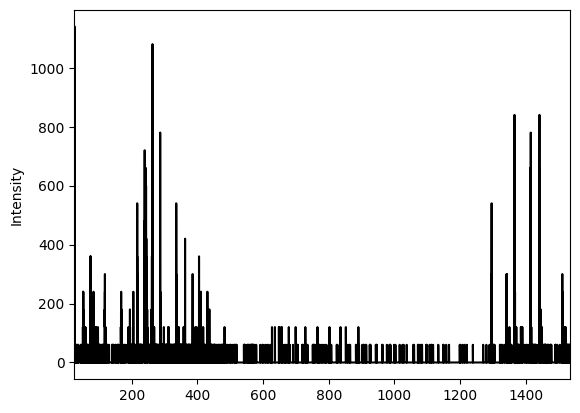

In [6]:
plot_intensity(seq,dt=1/60)

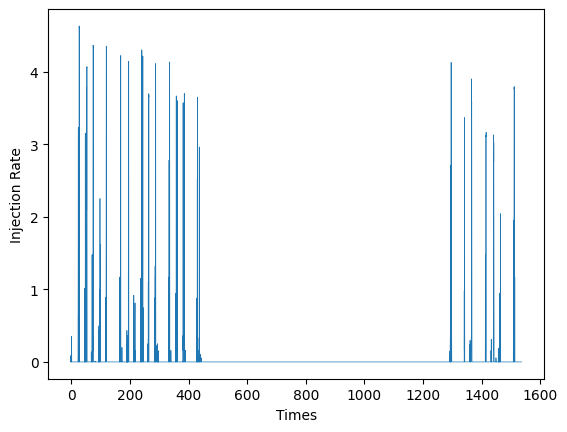

In [7]:
plt.xlabel('Times')
plt.ylabel('Injection Rate')
plt.plot(ts_time, ts,linewidth=0.5,color='tab:blue')

In [8]:
ts_time.shape, ts.shape
ts_time_filtered = ts_time[ts > 10]
print(ts_time_filtered)

tensor([])


In [9]:
t_arr = seq.arrival_times.cpu().numpy()
T0 =0 
T = float(seq.arrival_times.max())
dt =1/60
edges = np.arange(T0, T + dt, dt)

counts, _ = np.histogram(t_arr, bins=edges)
lam = counts / dt

In [10]:
lam.max()

np.float64(1140.0)

In [11]:
neg_index = np.where(ts < 0)
print(neg_index)

(array([], dtype=int64),)


In [12]:
indices = np.nonzero(lam > 500)[0]
indices/60

array([  25.83333333,   25.88333333,   25.91666667,   25.93333333,
         25.96666667,   25.98333333,   26.        ,   26.01666667,
         26.03333333,   26.05      ,   26.06666667,   26.08333333,
         26.1       ,   26.11666667,  216.88333333,  239.3       ,
        239.4       ,  239.5       ,  239.56666667,  239.65      ,
        242.98333333,  243.4       ,  243.48333333,  243.73333333,
        263.18333333,  263.23333333,  263.3       ,  263.31666667,
        263.33333333,  263.35      ,  263.36666667,  263.38333333,
        263.4       ,  263.41666667,  263.43333333,  263.45      ,
        263.46666667,  263.48333333,  263.5       ,  263.51666667,
        263.53333333,  263.55      ,  263.56666667,  263.58333333,
        263.6       ,  263.63333333,  263.66666667,  263.68333333,
        263.7       ,  286.78333333,  286.81666667,  286.85      ,
        286.88333333, 1365.41666667, 1365.53333333, 1365.65      ,
       1365.66666667, 1365.75      , 1365.85      , 1365.86666

In [13]:
ts_count, edges = np.histogram(t_arr, bins=ts_time)
ts_ = (ts[1:]+ts[:-1])/2
ts_time_ = (ts_time[1:] + ts_time[:-1]) / 2

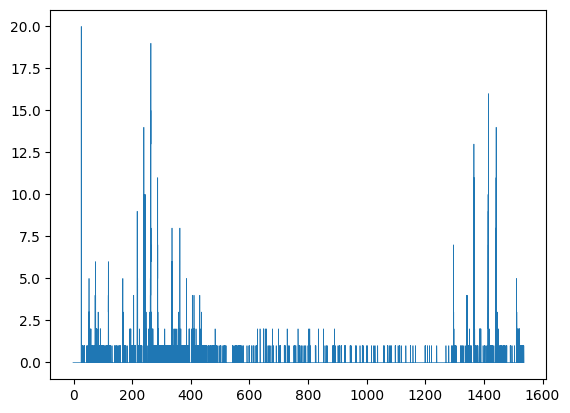

In [14]:
plt.plot(ts_time_, ts_count,linewidth=0.5,color='tab:blue')
# plt.plot(ts_time, ts)

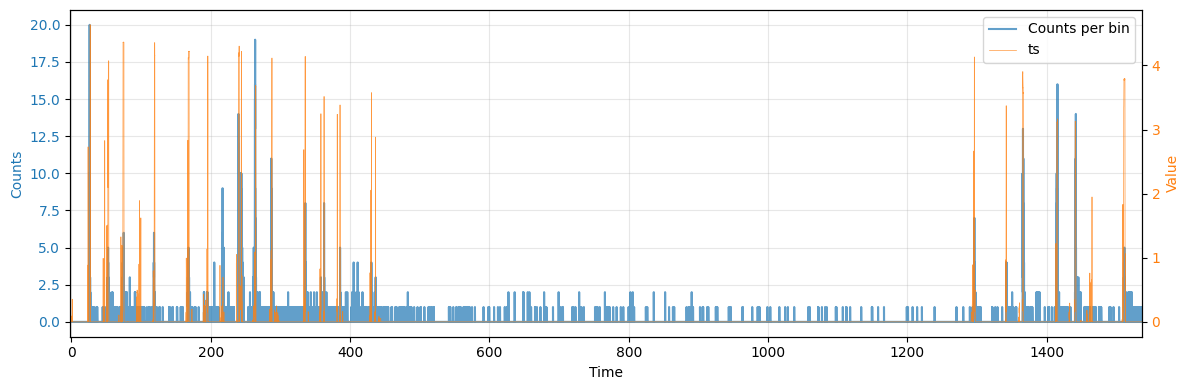

In [15]:
fig, ax1 = plt.subplots(figsize=(12, 4))
l1 = ax1.plot(ts_time[1:].numpy(), ts_count, label="Counts per bin", color="C0", alpha=0.7)
ax1.set_xlabel("Time")
ax1.set_ylabel("Counts", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")
ax1.set_xlim(ts_time.min().item(), ts_time.max().item())
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
l2 = ax2.plot(ts_time_.numpy(), ts_.numpy(), label="ts", color="C1", alpha=0.8,linewidth=0.5)
ax2.set_ylabel("Value", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")

lines = l1 + l2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper right")
fig.tight_layout()

In [16]:
start = pd.to_datetime("2018-10-15 12:00:00")
end1 = pd.to_datetime("2018-10-25 13:28:00")
end2 = pd.to_datetime("2018-10-25 13:55:00")
diff_hour1 = (end1 - start) / pd.Timedelta(hours=1)
diff_hour2 = (end2 - start) / pd.Timedelta(hours=1)
print(diff_hour1)
print(diff_hour2)


241.46666666666667
241.91666666666666


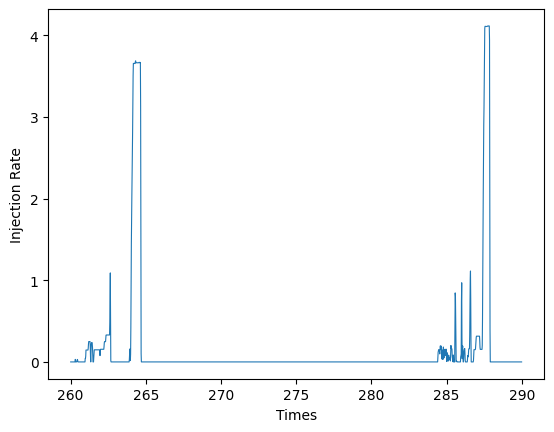

In [22]:
window_start = 260
window_len =30
window_end = window_start + window_len
mask  = (ts_time_ >= window_start) & (ts_time_ <= window_end)
plt.xlabel('Times')
plt.ylabel('Injection Rate')
plt.plot(ts_time_[mask], ts_[mask],linewidth=0.8,color='tab:blue')

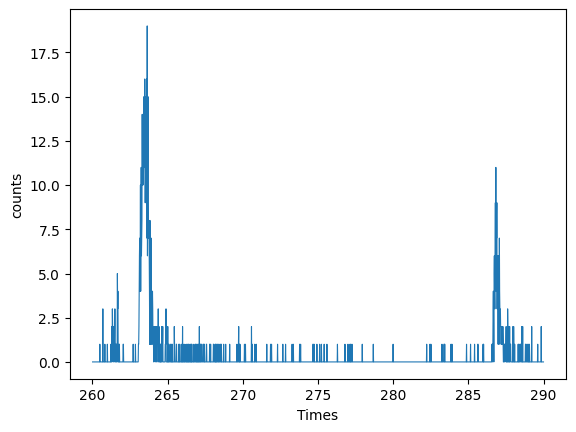

In [18]:
plt.xlabel('Times')
plt.ylabel('counts')
plt.plot(ts_time_[mask], ts_count[mask],linewidth=0.8,color='tab:blue')

In [19]:
inj_sum = ts_[mask].sum() 
count_sum = ts_count[mask].sum()
ratio =  count_sum/inj_sum
print(f'injection sum: {inj_sum}, count sum: {count_sum}, ratio: {ratio}')  

injection sum: 285.0409240722656, count sum: 890, ratio: 3.122358560562134
